This notebook walks through the process of constructing a similarity graph using the axelrodVoice package.

In [1]:
from axelrodVoice import SimilarityGraph
import axelrodVoice.strategies as axlV
import pandas as pd

Define the subject and opponent strategies. Subjects are graphed based on their matches with opponents.

In [2]:
subjects = [s() for s in [axlV.Cooperator, axlV.Defector, axlV.Grudger, axlV.TitForTat]]
opponents = [o() for o in [axlV.Cooperator, axlV.Defector, axlV.Liar, axlV.TestD7]]

Generate data from the matches, then create a graph object using that data.

In [3]:
SimilarityGraph.generate_data(subjects, opponents, last_round=100, filename="small_data.csv", seeds=[1])

...playing subject 1/4
...playing subject 2/4
...playing subject 3/4
...playing subject 4/4


,subject,opponent,seed,num_rounds,first_round,last_round,per_c,per_C,per_cC,per_cD,per_dC,per_dD,avg_score,avg_net_score
0,COOP,COOP,1,100,1,100,1.00,1.00,1.00,0.00,0.0,0.00,3.00,0.00
1,COOP,DEFT,1,100,1,100,1.00,1.00,1.00,0.00,0.0,0.00,0.00,-5.00
2,COOP,LIAR,1,100,1,100,1.00,1.00,1.00,0.00,0.0,0.00,0.00,-5.00
3,COOP,_d7,1,100,1,100,1.00,1.00,1.00,0.00,0.0,0.00,2.97,-0.05
4,DEFT,COOP,1,100,1,100,0.00,0.00,0.00,0.00,0.0,1.00,5.00,5.00
5,DEFT,DEFT,1,100,1,100,0.00,0.00,0.00,0.00,0.0,1.00,1.00,0.00
6,DEFT,LIAR,1,100,1,100,0.00,0.00,0.00,0.00,0.0,1.00,1.00,0.00
7,DEFT,_d7,1,100,1,100,0.00,0.00,0.00,0.00,0.0,1.00,4.96,4.95
8,GRUD,COOP,1,100,1,100,1.00,1.00,1.00,0.00,0.0,0.00,3.00,0.00
9,GRUD,DEFT,1,100,1,100,0.01,0.00,0.00,0.01,0.0,0.99,1.00,0.00


In [4]:
graph = SimilarityGraph("small_data.csv")

In [5]:
behaviors = ["per_cC", "per_cD", "per_dC", "per_dD"]
(graph.full_data.sort_values(by=['opponent', 'seed', 'subject'])
         .loc[:, ["opponent", "subject"] + behaviors]
         .reset_index(drop=True)
         .assign(max_behavior_val= lambda df: df.max(axis=1,numeric_only=True),
                 max_behavior_name= lambda df: df.idxmax(axis=1,numeric_only=True))
         .assign(max_behavior = lambda df:
                 df.apply(lambda row: f"{row['max_behavior_val']:.0%} {row['max_behavior_name'][4:]}", axis=1))
         .loc[:, ["opponent", "subject", "max_behavior"]]
         .pivot(index="subject", columns="opponent", values="max_behavior")
         )

opponent,COOP,DEFT,LIAR,_d7
subject,,,,
COOP,100% cC,100% cC,100% cC,100% cC
DEFT,100% dD,100% dD,100% dD,100% dD
GRUD,100% cC,99% dD,99% cD,93% dD
TIFT,100% cC,99% dD,99% cD,99% cC


In [6]:
# Create clusters using behaviors
s_names = [s.name for s in subjects]
o_names = [o.name for o in opponents]

graph.partition_by_metric_and_threshold(
    behaviors=behaviors,
    threshold=0.10,
    subjects=s_names, opponents=o_names,
    start=1, end=100)

,cluster
0,"(COOP, GRUD, TIFT)"
1,"(DEFT, GRUD, TIFT)"
2,"(GRUD, TIFT)"
3,"(COOP, TIFT)"
4,"(DEFT, GRUD)"


C:\Users\alexd\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\networkx\drawing\nx_pylab.py:457: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  node_collection = ax.scatter(


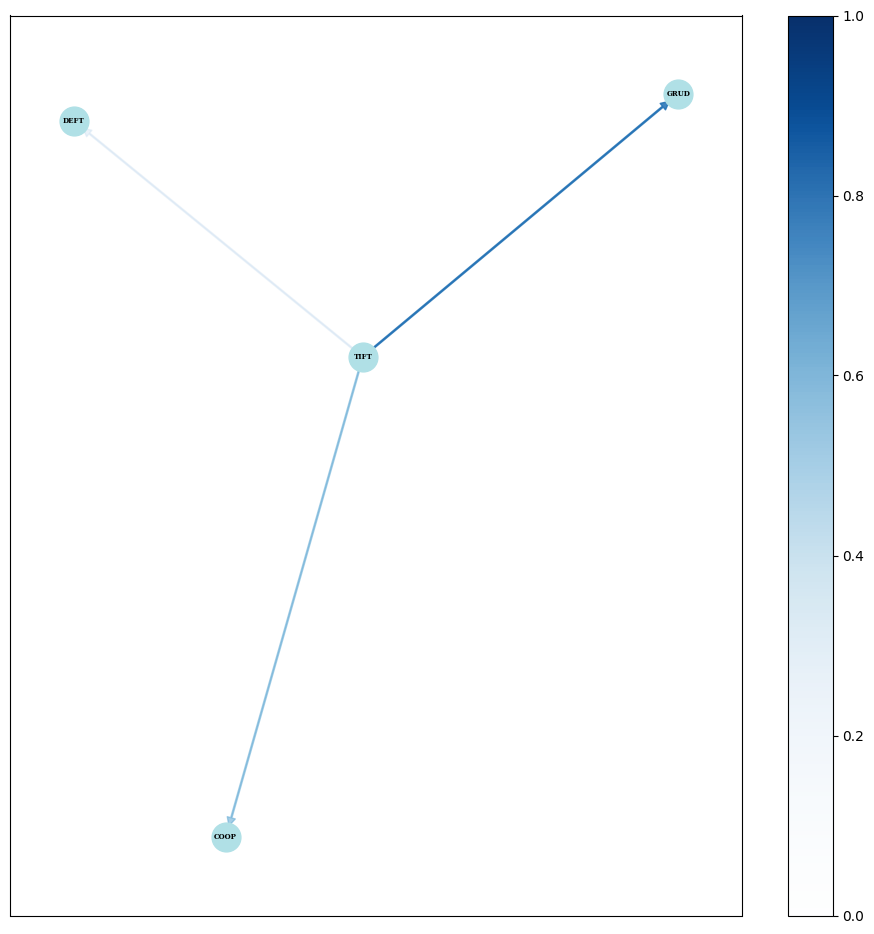

In [7]:
# Figure 5.1.2a
adj_mat = graph.partitions_to_freq_tbl()
custom_adj = pd.DataFrame(0.0, index=s_names, columns=s_names)
custom_adj[ custom_adj.index == 'TIFT' ] = adj_mat[ adj_mat.index == 'TIFT' ]
graph.draw_similarity_graph(adj_matrix=custom_adj)

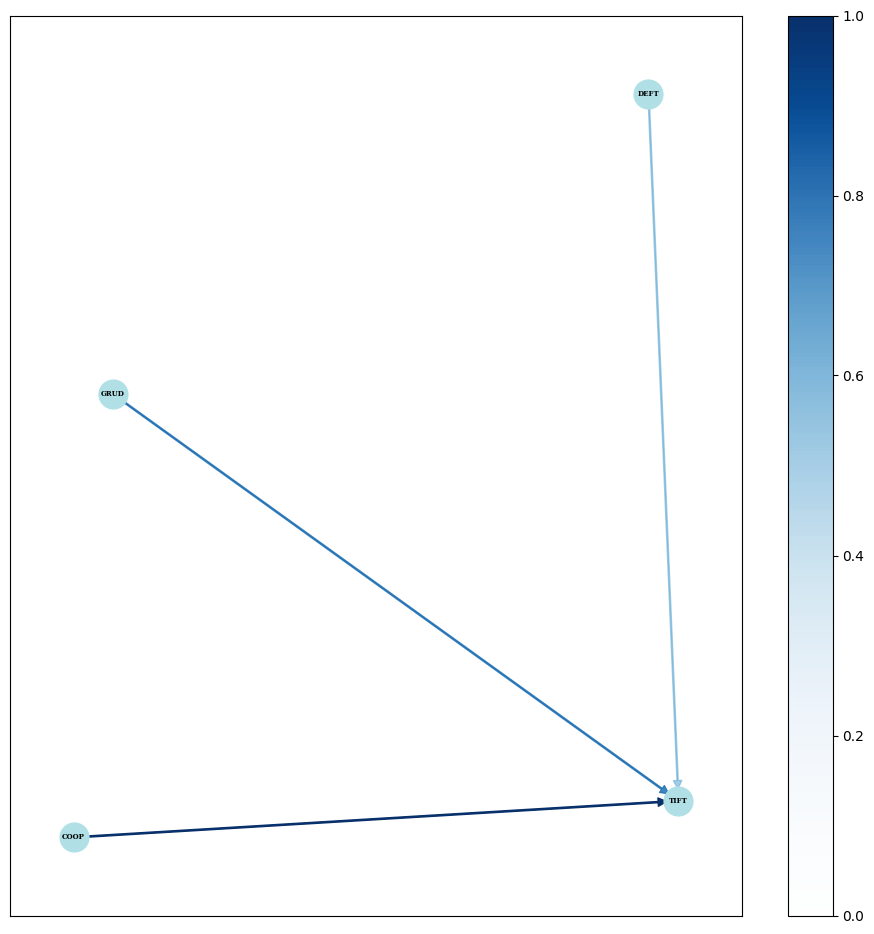

In [8]:
# Figure 5.1.2b
custom_adj = pd.DataFrame(0.0, index=s_names, columns=s_names)
custom_adj['TIFT'] = adj_mat['TIFT']
graph.draw_similarity_graph(adj_matrix=custom_adj)

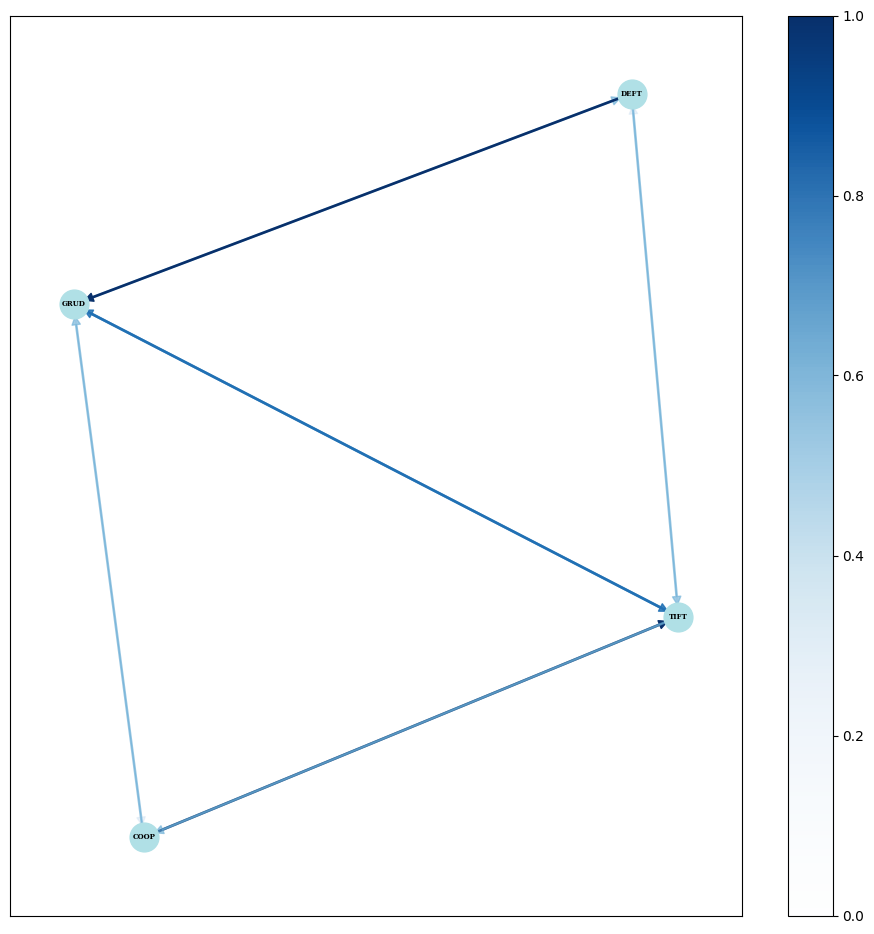

In [9]:
# Figure 5.1.2c
graph.draw_similarity_graph()